## Statistical Analysis and A/B Testing

## Objectives

1. Load the processed `customer_data` produced by `data_manipulation.ipynb`.
2. Test whether revenue differs significantly between two acquisition channels (Paid Search vs. Organic) - a real budget-allocation question a business would ask.
3. Test whether margin differs significantly between discounted and full-price orders, formally confirming the pattern seen visually in `eda.ipynb`.
4. Report effect sizes alongside p-values - statistical significance alone doesn't tell you whether a difference is large enough to act on.

In [19]:
%matplotlib inline

# Core Python utilities
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd
from scipy import stats

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Pandas display settings: readable but not noisy
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11


In [20]:
%%capture
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Processed data folder:", PROCESSED_DATA_DIR)
print("Reports folder:", REPORTS_DIR)

### Load Processed Data

In [21]:
customer_data = pd.read_csv(PROCESSED_DATA_DIR / "customer_data.csv")

print(f"Rows: {customer_data.shape[0]:,}")
print(f"Columns: {customer_data.shape[1]:,}")

customer_data.head()

Rows: 3,305
Columns: 15


,order_id,customer_id,order_date,discount_rate,signup_date,country,channel,order_item_id,product_id,quantity,revenue,margin,category,unit_cost,price
0,ORD000001,CUST0001,2024-10-31,0.20,2024-11-23,UK,Organic,ITEM0000001,PROD005,5,"1,465.44",622.79,Mobile,168.53,366.36
1,ORD000001,CUST0001,2024-10-31,0.20,2024-11-23,UK,Organic,ITEM0000002,PROD010,1,173.88,136.75,Mobile,37.13,217.35
2,ORD000001,CUST0001,2024-10-31,0.20,2024-11-23,UK,Organic,ITEM0000003,PROD010,1,173.88,136.75,Mobile,37.13,217.35
3,ORD000001,CUST0001,2024-10-31,0.20,2024-11-23,UK,Organic,ITEM0000004,PROD004,2,55.22,-30.94,Accessories,43.08,34.51
4,ORD000002,CUST0001,2024-09-27,0.00,2024-11-23,UK,Organic,ITEM0000005,PROD004,2,69.02,-17.14,Accessories,43.08,34.51


## 1. A/B Test: Paid Search vs. Organic (Revenue)

**Question**: does customer revenue differ significantly by acquisition channel?
 `channel` actually varies.

- **H0**: mean customer revenue is the same for Paid Search and Organic.
- **H1**: mean customer revenue differs between Paid Search and Organic.

In [22]:
customer_revenue = customer_data.groupby(["customer_id", "channel"])["revenue"].sum().reset_index()

paid_search = customer_revenue.loc[customer_revenue["channel"] == "Paid Search", "revenue"]
organic = customer_revenue.loc[customer_revenue["channel"] == "Organic", "revenue"]

print(f"Paid Search: n={len(paid_search)}, mean={paid_search.mean():,.2f}, std={paid_search.std():,.2f}")
print(f"Organic:     n={len(organic)}, mean={organic.mean():,.2f}, std={organic.std():,.2f}")

Paid Search: n=63, mean=13,598.97, std=7,089.48
Organic:     n=60, mean=13,924.38, std=8,090.22


In [23]:
# Check the equal-variance assumption before choosing the t-test variant
levene_stat, levene_p = stats.levene(paid_search, organic)
print(f"Levene's test for equal variances: statistic={levene_stat:.3f}, p={levene_p:.4f}")
equal_var = levene_p > 0.05
print("Assume equal variances:", equal_var, "-> using", "Student's" if equal_var else "Welch's", "t-test")

t_stat, p_value = stats.ttest_ind(paid_search, organic, equal_var=equal_var)

# Cohen's d effect size (pooled standard deviation)
pooled_std = np.sqrt(((len(paid_search) - 1) * paid_search.std()**2 + (len(organic) - 1) * organic.std()**2) / (len(paid_search) + len(organic) - 2))
cohens_d = (paid_search.mean() - organic.mean()) / pooled_std

print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Cohen's d: {cohens_d:.3f}")
print("Statistically significant at alpha=0.05:" , p_value < 0.05)

Levene's test for equal variances: statistic=3.461, p=0.0653
Assume equal variances: True -> using Student's t-test

t-statistic: -0.238
p-value: 0.8126
Cohen's d: -0.043
Statistically significant at alpha=0.05: False


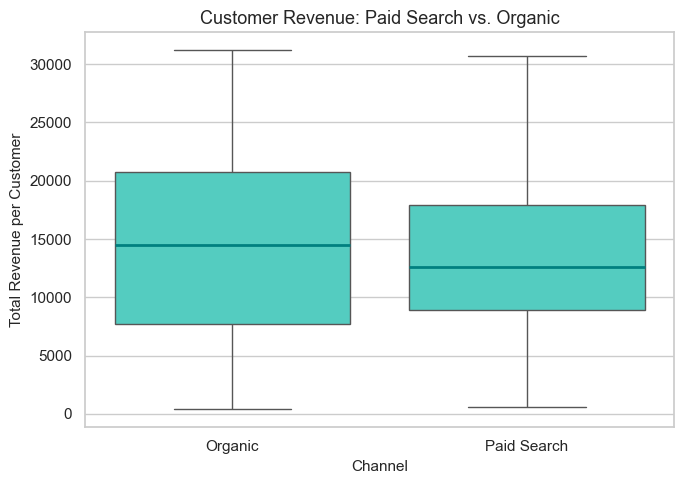

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=customer_revenue[customer_revenue["channel"].isin(["Paid Search", "Organic"])],
    x="channel", y="revenue", color="#40E0D0",
    medianprops={"color": "#008080", "linewidth": 2}, ax=ax,
)
ax.set_title("Customer Revenue: Paid Search vs. Organic")
ax.set_xlabel("Channel")
ax.set_ylabel("Total Revenue per Customer")

plt.tight_layout()
plt.show()

## 2. Discounted vs. Full-Price Orders (Margin)

**Question**: does order margin differ significantly between orders with a discount applied and orders at full price?

- **H0**: mean order margin is the same for discounted and full-price orders.
- **H1**: mean order margin differs between discounted and full-price orders.

In [25]:
order_margin = customer_data.groupby(["order_id", "discount_rate"])["margin"].sum().reset_index()
order_margin["discounted"] = np.where(order_margin["discount_rate"] > 0, "Discounted", "Full Price")

full_price = order_margin.loc[order_margin["discounted"] == "Full Price", "margin"]
discounted = order_margin.loc[order_margin["discounted"] == "Discounted", "margin"]

print(f"Full Price:  n={len(full_price)}, mean={full_price.mean():,.2f}, std={full_price.std():,.2f}")
print(f"Discounted:  n={len(discounted)}, mean={discounted.mean():,.2f}, std={discounted.std():,.2f}")

Full Price:  n=255, mean=1,511.41, std=1,558.32
Discounted:  n=1068, mean=1,260.90, std=1,445.19


In [26]:
levene_stat, levene_p = stats.levene(full_price, discounted)
print(f"Levene's test for equal variances: statistic={levene_stat:.3f}, p={levene_p:.4f}")
equal_var = levene_p > 0.05
print("Assume equal variances:", equal_var, "-> using", "Student's" if equal_var else "Welch's", "t-test")

t_stat, p_value = stats.ttest_ind(full_price, discounted, equal_var=equal_var)

pooled_std = np.sqrt(((len(full_price) - 1) * full_price.std()**2 + (len(discounted) - 1) * discounted.std()**2) / (len(full_price) + len(discounted) - 2))
cohens_d = (full_price.mean() - discounted.mean()) / pooled_std

print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Cohen's d: {cohens_d:.3f}")
print("Statistically significant at alpha=0.05:", p_value < 0.05)

Levene's test for equal variances: statistic=0.591, p=0.4420
Assume equal variances: True -> using Student's t-test

t-statistic: 2.449
p-value: 0.0145
Cohen's d: 0.171
Statistically significant at alpha=0.05: True


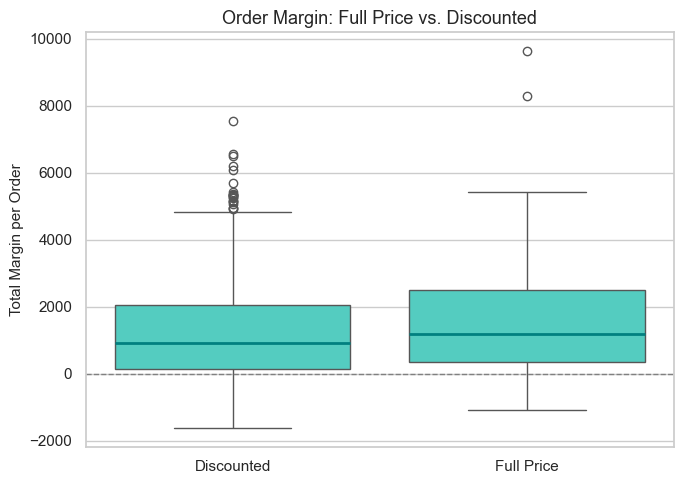

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=order_margin, x="discounted", y="margin", color="#40E0D0",
    medianprops={"color": "#008080", "linewidth": 2}, ax=ax,
)
ax.axhline(0, color="grey", linestyle="--", linewidth=1)
ax.set_title("Order Margin: Full Price vs. Discounted")
ax.set_xlabel("")
ax.set_ylabel("Total Margin per Order")

plt.tight_layout()
plt.show()

### Correcting for Non-Independence

The order-level test above treats each of the 1,068 discounted orders and 255 full-price orders as independent observations. They aren't: only 250 customers generated all of them, and 145 customers appear in **both** groups (averaging 4.3 discounted orders and 1.7 full-price orders each). Repeated orders from the same customer are correlated - same buying habits, same product mix - so the two-sample t-test above understates its own uncertainty, and the p=0.0145 result can't be trusted at face value.

A paired test on those 145 customers - each customer's own average full-price margin vs. their own average discounted margin - controls for this directly and answers the more useful question: for the same customer, does discounting lower margin?

In [28]:
# Average order margin per customer, split by discount status - keep only customers with both
order_margin_customer = order_margin.merge(
    customer_data[["order_id", "customer_id"]].drop_duplicates(), on="order_id"
)

customer_avg_margin = (
    order_margin_customer
    .groupby(["customer_id", "discounted"])["margin"]
    .mean()
    .unstack("discounted")
    .dropna(subset=["Full Price", "Discounted"])
)

print(f"Customers with both full-price and discounted orders: {len(customer_avg_margin)}")
customer_avg_margin.describe()

Customers with both full-price and discounted orders: 145


discounted,Discounted,Full Price
count,145.00,145.00
mean,"1,221.58","1,394.63"
std,818.14,"1,209.93"
min,-668.95,"-1,099.39"
25%,734.60,432.03
50%,"1,108.58","1,339.40"
75%,"1,727.53","2,120.67"
max,"5,156.96","5,426.16"


In [29]:
diff = customer_avg_margin["Full Price"] - customer_avg_margin["Discounted"]

# Check normality of the paired differences before trusting the paired t-test
shapiro_stat, shapiro_p = stats.shapiro(diff)
print(f"Shapiro-Wilk test on paired differences: statistic={shapiro_stat:.3f}, p={shapiro_p:.4f}")

t_stat, p_value = stats.ttest_rel(customer_avg_margin["Full Price"], customer_avg_margin["Discounted"])
w_stat, w_p_value = stats.wilcoxon(diff)
cohens_d_paired = diff.mean() / diff.std()

print(f"\nPaired t-test: t={t_stat:.3f}, p={p_value:.4f}")
print(f"Wilcoxon signed-rank (nonparametric check): statistic={w_stat:.3f}, p={w_p_value:.4f}")
print(f"Paired Cohen's d: {cohens_d_paired:.3f}")
print("Statistically significant at alpha=0.05:", p_value < 0.05)

Shapiro-Wilk test on paired differences: statistic=0.991, p=0.4896

Paired t-test: t=1.337, p=0.1834
Wilcoxon signed-rank (nonparametric check): statistic=4688.000, p=0.2328
Paired Cohen's d: 0.111
Statistically significant at alpha=0.05: False


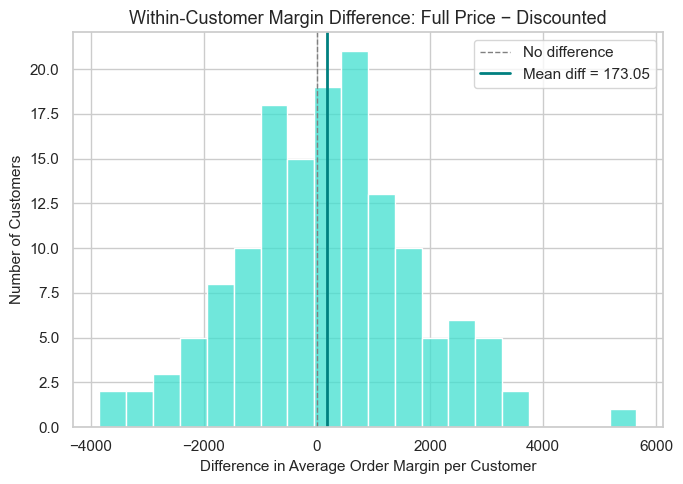

In [30]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(diff, bins=20, color="#40E0D0", ax=ax)
ax.axvline(0, color="grey", linestyle="--", linewidth=1, label="No difference")
ax.axvline(diff.mean(), color="#008080", linestyle="-", linewidth=2, label=f"Mean diff = {diff.mean():,.2f}")
ax.set_title("Within-Customer Margin Difference: Full Price − Discounted")
ax.set_xlabel("Difference in Average Order Margin per Customer")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

## Conclusion

I ran two hypothesis tests, both aggregated to the correct unit of analysis rather than testing on raw line items, since testing at the wrong grain would have overstated the sample size and risked a false positive.

**Channel test (Paid Search vs. Organic, customer-level revenue)**: mean revenue was 13,598.97 for Paid Search vs. 13,924.38 for Organic - close enough that I could not reject the null hypothesis (p=0.81, Cohen's d=-0.04, a negligible effect). This means I don't have evidence from this data that one channel acquires more valuable customers than the other. That's a useful negative result: channel choice shouldn't be driven by an assumed revenue difference, since none was detected here.

**Discount test (Full Price vs. Discounted, order-level margin)**: the initial order-level t-test suggested a significant difference (p=0.0145), but that test treats each order as an independent observation when in fact the 1,068 discounted and 255 full-price orders come from only 250 customers, 145 of whom appear in both groups with several repeated, correlated orders each. Re-running the comparison as a **paired test** on those 145 customers - each customer's own average full-price margin vs. their own average discounted margin - controls for that correlation directly, and it changes the conclusion: paired t=1.34, p=0.183 (Wilcoxon p=0.233, confirming the result isn't an artifact of non-normal differences), with a small effect size (paired Cohen's d=0.11). Once the same-customer correlation is accounted for, there isn't reliable evidence that discounting lowers margin for a given customer - the earlier "significant" result was very likely a false positive from treating repeated orders as independent.

Put together, neither test supports acting on the pattern that looked significant in the raw, order-level view. Channel doesn't predict customer value, and once you control for who is placing the orders, discounting doesn't show a reliable within-customer margin cost either. This is a case where getting the unit of analysis right reversed the practical recommendation: don't restructure discount policy based on this data. If margin impact is still a concern, it's worth revisiting with a properly randomized A/B test on discount eligibility rather than relying on observational, non-random discount assignment.